In [1]:
import yfinance as yf
import os
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### ***Fetching Gold Data from Yahoo Finance***

In [2]:
gold_ticker = 'GC=F'
end_date = pd.Timestamp.today()
start_date = end_date - pd.DateOffset(years=10)
gold_data = yf.download(gold_ticker, start=start_date, end=end_date)

/tmp/ipykernel_218/2428066834.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  gold_data = yf.download(gold_ticker, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed


In [3]:
gold_data.head()

Price,Close,High,Low,Open,Volume
Ticker,GC=F,GC=F,GC=F,GC=F,GC=F
Date,,,,,
2016-03-04,1269.900024,1279.900024,1250.900024,1263.000000,268
2016-03-07,1263.199951,1272.300049,1259.699951,1259.800049,67
2016-03-08,1262.099976,1276.300049,1261.000000,1268.699951,43
2016-03-09,1256.599976,1260.000000,1244.800049,1254.500000,79
2016-03-10,1272.000000,1273.000000,1237.500000,1250.000000,119


### ***Copying Data***

In [4]:
gold_df = pd.DataFrame(gold_data)
gold_df.columns = gold_df.columns.droplevel('Ticker')
gold_df.columns.name = None
gold_df = gold_df.reset_index()
gold_df.head()

,Date,Close,High,Low,Open,Volume
0,2016-03-04,1269.900024,1279.900024,1250.900024,1263.000000,268
1,2016-03-07,1263.199951,1272.300049,1259.699951,1259.800049,67
2,2016-03-08,1262.099976,1276.300049,1261.000000,1268.699951,43
3,2016-03-09,1256.599976,1260.000000,1244.800049,1254.500000,79
4,2016-03-10,1272.000000,1273.000000,1237.500000,1250.000000,119


In [5]:
gold_df.to_csv("gold_10_years.csv", index=False)

### ***Basic Info***

In [6]:
gold_df.shape

(2513, 6)

In [7]:
gold_df.dtypes

,0
Date,datetime64[ns]
Close,float64
High,float64
Low,float64
Open,float64
Volume,int64


**About Missing Values**

In [8]:
gold_df.isna().sum()

,0
Date,0
Close,0
High,0
Low,0
Open,0
Volume,0


**About Duplicate Values**

In [9]:
gold_df.duplicated().sum()

np.int64(0)

### ***Visualization***

In [10]:
gold_df.columns

Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object')

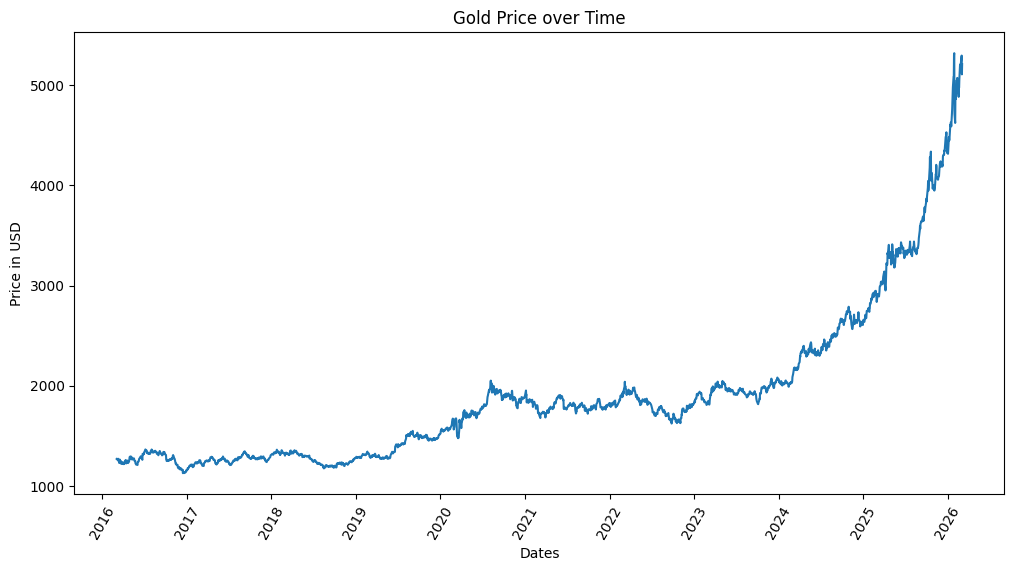

In [11]:
plt.figure(figsize=(12, 6))
sns.lineplot(gold_df, x='Date', y='Close')
plt.title("Gold Price over Time")
plt.xticks(rotation=60)
plt.xlabel("Dates")
plt.ylabel("Price in USD")
plt.show()

In [15]:
!pip install mplfinance

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.0/75.0 kB 3.1 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/mplfinance/_arg_validators.py:84: UserWarning:




            POSSIBLE TO SEE DETAILS (Candles, Ohlc-Bars, Etc.)
   For more information see:
   - https://github.com/matplotlib/mplfinance/wiki/Plotting-Too-Much-Data
   
   TO SILENCE THIS WARNING, set `type='line'` in `mpf.plot()`
   OR set kwarg `warn_too_much_data=N` where N is an integer 
   LARGER than the number of data points you want to plot.




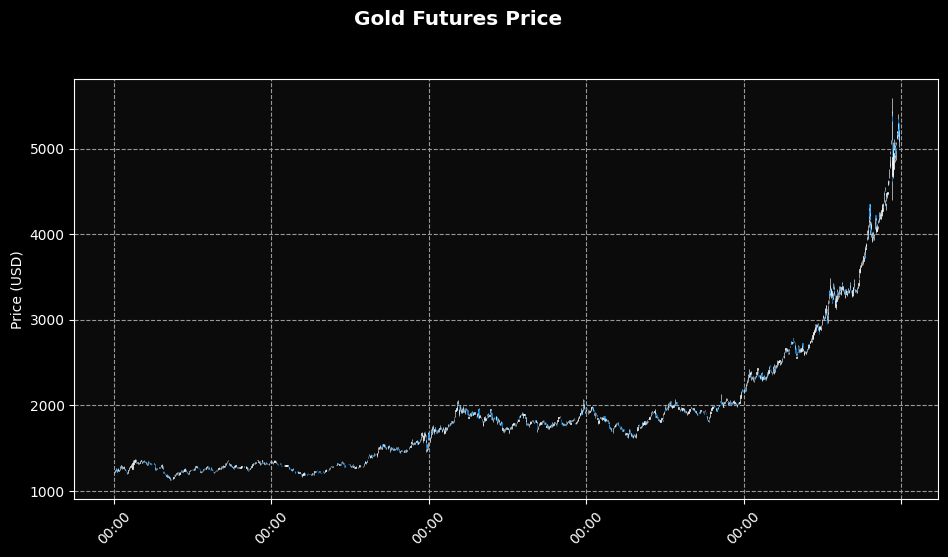

In [18]:
mpf.plot(
    gold_df,
    type='candle',
    style='nightclouds',
    title='Gold Futures Price',
    ylabel='Price (USD)',
    volume=False,
    figsize=(12,6)
)

In [19]:
gold_df['Year'] = gold_df['Date'].dt.year
gold_df.head()

,Date,Close,High,Low,Open,Volume,Daily_Return,SMA_5,SMA_20,EMA_12,EMA_26,MACD,Year
1970-01-01 00:00:00.000000019,2016-04-01,1222.199951,1235.199951,1209.199951,1232.300049,1602,-0.009723,1227.759985,1244.039996,1233.440395,1238.369738,-4.929343,2016
1970-01-01 00:00:00.000000020,2016-04-04,1218.000000,1222.300049,1215.000000,1221.699951,2038,-0.003436,1227.379980,1241.444995,1230.991602,1236.486815,-5.495213,2016
1970-01-01 00:00:00.000000021,2016-04-05,1228.400024,1236.699951,1215.400024,1215.400024,477,0.008539,1225.939990,1239.704999,1230.582530,1235.752773,-5.170244,2016
1970-01-01 00:00:00.000000022,2016-04-06,1222.500000,1230.400024,1217.599976,1230.400024,248,-0.004803,1225.059985,1237.725000,1229.311813,1234.569569,-5.257756,2016
1970-01-01 00:00:00.000000023,2016-04-07,1236.199951,1242.900024,1224.599976,1224.800049,375,0.011207,1225.459985,1236.704999,1230.391111,1234.712949,-4.321837,2016


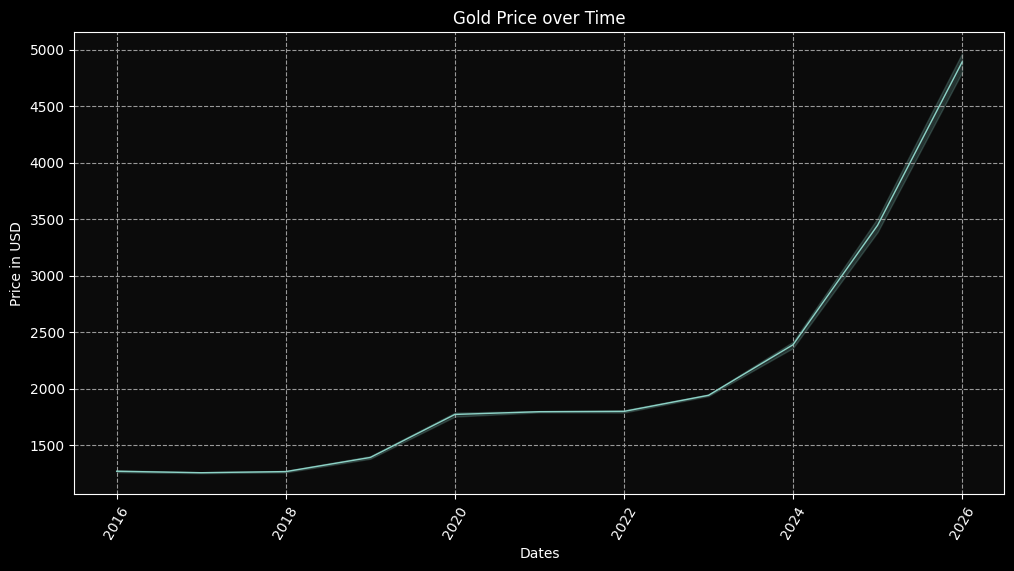

In [20]:
plt.figure(figsize=(12, 6))
sns.lineplot(gold_df, x='Year', y='Close')
plt.title("Gold Price over Time")
plt.xticks(rotation=60)
plt.xlabel("Dates")
plt.ylabel("Price in USD")
plt.show()


**Feature Engineering**

In [13]:
# Add more meaningful features
gold_df['Daily_Return'] = gold_df['Close'].pct_change()
gold_df['SMA_5'] = gold_df['Close'].rolling(5).mean()
gold_df['SMA_20'] = gold_df['Close'].rolling(20).mean()
gold_df['EMA_12'] = gold_df['Close'].ewm(span=12).mean()
gold_df['EMA_26'] = gold_df['Close'].ewm(span=26).mean()
gold_df['MACD'] = gold_df['EMA_12'] - gold_df['EMA_26']

# Drop NA values created by rolling windows
gold_df.dropna(inplace=True)

# Update numerical columns
numerical_cols = ['Open', 'High', 'Low', 'Close', 'Volume',
                 'Daily_Return', 'SMA_5', 'SMA_20', 'MACD']

In [21]:
gold_df.head(3)

,Date,Close,High,Low,Open,Volume,Daily_Return,SMA_5,SMA_20,EMA_12,EMA_26,MACD,Year
1970-01-01 00:00:00.000000019,2016-04-01,1222.199951,1235.199951,1209.199951,1232.300049,1602,-0.009723,1227.759985,1244.039996,1233.440395,1238.369738,-4.929343,2016
1970-01-01 00:00:00.000000020,2016-04-04,1218.000000,1222.300049,1215.000000,1221.699951,2038,-0.003436,1227.379980,1241.444995,1230.991602,1236.486815,-5.495213,2016
1970-01-01 00:00:00.000000021,2016-04-05,1228.400024,1236.699951,1215.400024,1215.400024,477,0.008539,1225.939990,1239.704999,1230.582530,1235.752773,-5.170244,2016


In [22]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

scaled_df = scaler.fit_transform(gold_df[numerical_cols])
scaled_data = scaler.fit_transform(gold_df[['Close']].values)

## **Models**

In [ ]:
all_results = []

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
def evaluate_model(model, X_test, y_test, name):
    predictions = model.predict(X_test)
    predictions = scaler.inverse_transform(predictions)
    y_true = scaler.inverse_transform(y_test)

    mae = mean_absolute_error(y_true, predictions)
    mse = mean_squared_error(y_true, predictions)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, predictions)

    print(f"\n{name} Evaluation:")
    print(f"MAE : {mae:.2f}")
    print(f"MSE : {mse:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R²  : {r2:.2f}")

    res = {
        'Model Name': name,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R2': r2
    }

    return res


### Sequences

In [ ]:
def create_sequences(data, seq_length=20):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

In [ ]:
SEQ_LEN = 30
X, y = create_sequences(scaled_data, SEQ_LEN)

In [ ]:
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

**RandomForest Regressor**

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

# Prepare data for Random Forest
def prepare_rf_data(data, seq_length=30):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length].flatten())
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

# Prepare sequences for Random Forest
X_rf, y_rf = prepare_rf_data(scaled_data, SEQ_LEN)

# Split data
X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(
    X_rf, y_rf, test_size=0.2, random_state=42, shuffle=False
)

# Define the parameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

# Initialize the base model
rf = RandomForestRegressor(random_state=42, n_jobs=-1)

# Initialize GridSearchCV
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    n_jobs=-1,
    verbose=2,
    scoring='neg_mean_squared_error'
)

# Fit the grid search to the data
grid_search.fit(X_train_rf, y_train_rf.ravel())

# Get the best parameters
best_params = grid_search.best_params_
print(f"Best parameters found: {best_params}")

# Get the best model
best_rf = grid_search.best_estimator_

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Best parameters found: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 200}


In [ ]:
def rf_evaluate_model(model, X_test, y_test, name):
    predictions = model.predict(X_test)

    # Reshape predictions and y_test for inverse transform
    predictions = predictions.reshape(-1, 1)
    y_test = y_test.reshape(-1, 1)

    predictions = scaler.inverse_transform(predictions)
    y_true = scaler.inverse_transform(y_test)

    mae = mean_absolute_error(y_true, predictions)
    mse = mean_squared_error(y_true, predictions)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, predictions)

    print(f"\n{name} Evaluation:")
    print(f"MAE : {mae:.2f}")
    print(f"MSE : {mse:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R²  : {r2:.2f}")

    res = {
        'Model Name': name,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R2': r2
    }

    return res

In [ ]:
rf_results = rf_evaluate_model(best_rf, X_test_rf, y_test_rf, "Tuned Random Forest")
all_results.append(rf_results)


Tuned Random Forest Evaluation:
MAE : 542.15
MSE : 500263.52
RMSE: 707.29
R²  : -1.26


**ANN Model**

In [ ]:
def prepare_lr_data(data, seq_length=20):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length].flatten())  # Flatten the sequence
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

X_lr, y_lr = prepare_lr_data(scaled_data, SEQ_LEN)

In [ ]:
from sklearn.model_selection import train_test_split
X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(X_lr, y_lr, test_size=0.2, random_state=42, shuffle=False)

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, LSTM, GRU, Dropout, BatchNormalization, Input
from tensorflow.keras.regularizers import l2

In [ ]:
def build_ann_model(input_shape):
    model = Sequential([
        Input(input_shape),
        Dense(64, activation='relu'),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

In [ ]:
X_ann, y_ann = X_lr, y_lr  # Reuse the flattened sequences
X_train_ann, X_test_ann = X_train_lr, X_test_lr
y_train_ann, y_test_ann = y_train_lr, y_test_lr

In [ ]:
ann_model = build_ann_model((X_train_ann.shape[1],))
ann_model.fit(X_train_ann, y_train_ann, epochs=30, batch_size=8, verbose=1)

Epoch 1/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.0067
Epoch 2/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0014
Epoch 3/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 9.3343e-04
Epoch 4/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 8.2609e-04
Epoch 5/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 6.8388e-04
Epoch 6/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 7.0738e-04
Epoch 7/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 5.5582e-04
Epoch 8/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 5.6568e-04
Epoch 9/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4.9610e-04
Epoch 10/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4.6385e-04
Epoch 11/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4.9378e-04
Epoch 12/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 3.2048e-04
Epoch 13/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4.0274e-04
Epoch 14/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 3.3664e-04
Epoch 15/

In [ ]:
ann_results = evaluate_model(ann_model, X_test_lr, y_test_lr, 'ANN')
all_results.append(ann_results)

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 

ANN Evaluation:
MAE : 370.09
MSE : 164495.30
RMSE: 405.58
R²  : 0.26


**RNN Model**

In [ ]:
def build_rnn_model(input_shape):
    model = Sequential()
    model.add(Input(input_shape))
    model.add(SimpleRNN(128, return_sequences=True))
    model.add(Dropout(0.2))
    model.add(SimpleRNN(64, return_sequences=True))
    model.add(Dropout(0.2))
    model.add(SimpleRNN(32, return_sequences=True))
    model.add(Dropout(0.2))
    model.add(SimpleRNN(16))
    model.add(Dense(8, activation='relu'))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse')
    return model

In [ ]:
input_shape = (X_train.shape[1], X_train.shape[2])

# RNN
rnn_model = build_rnn_model(input_shape)
rnn_model.fit(X_train, y_train, epochs=30, batch_size=8, verbose=1)

Epoch 1/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - loss: 0.0497
Epoch 2/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.0215
Epoch 3/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.0130
Epoch 4/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 0.0044
Epoch 5/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.0020
Epoch 6/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.0016
Epoch 7/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - loss: 0.0016
Epoch 8/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.0017
Epoch 9/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - loss: 0.0013
Epoch 10/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.0014
Epoch 11/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.0014
Epoch 12/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.0015
Epoch 13/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.0014
Epoch 14/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - loss: 0.0016
Epoch 15/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 4s

In [ ]:
rnn_metrics = evaluate_model(rnn_model, X_test, y_test, "RNN")
all_results.append(rnn_metrics)

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step

RNN Evaluation:
MAE : 684.50
MSE : 721355.70
RMSE: 849.33
R²  : -2.26


**LSTM Model**

In [ ]:
def build_lstm_model(input_shape):
    model = Sequential()
    model.add(Input(input_shape))
    model.add(LSTM(128, return_sequences=True))
    model.add(Dropout(0.2))
    model.add(LSTM(64, return_sequences=True))
    model.add(Dropout(0.2))
    model.add(LSTM(32, return_sequences=True))
    model.add(Dropout(0.2))
    model.add(LSTM(16))
    model.add(Dense(8, activation='relu'))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse')
    return model

In [ ]:
# LSTM
lstm_model = build_lstm_model(input_shape)
lstm_model.fit(X_train, y_train, epochs=30, batch_size=8, verbose=1)

Epoch 1/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 14s 33ms/step - loss: 0.0044
Epoch 2/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 10s 40ms/step - loss: 6.2793e-04
Epoch 3/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 10s 39ms/step - loss: 4.1425e-04
Epoch 4/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 10s 39ms/step - loss: 3.5912e-04
Epoch 5/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 10s 39ms/step - loss: 3.0979e-04
Epoch 6/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 10s 40ms/step - loss: 2.9595e-04
Epoch 7/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 10s 39ms/step - loss: 3.0764e-04
Epoch 8/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 10s 39ms/step - loss: 3.0033e-04
Epoch 9/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 10s 39ms/step - loss: 2.7498e-04
Epoch 10/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 10s 39ms/step - loss: 2.8273e-04
Epoch 11/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 10s 39ms/step - loss: 2.8267e-04
Epoch 12/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 10s 40ms/step - loss: 2.5002e-04
Epoch 13/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 10s 39ms/step - loss: 2.3016e-04
Epoch 14/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 10s 39ms/s

In [ ]:
lstm_metrics = evaluate_model(lstm_model, X_test, y_test, "LSTM")
all_results.append(lstm_metrics)

16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step

LSTM Evaluation:
MAE : 275.12
MSE : 150761.24
RMSE: 388.28
R²  : 0.32


**GRU**

In [ ]:
def build_gru_model(input_shape):
    model = Sequential()
    model.add(Input(input_shape))
    model.add(GRU(128, return_sequences=True))
    model.add(Dropout(0.2))
    model.add(GRU(64, return_sequences=True))
    model.add(Dropout(0.2))
    model.add(GRU(32, return_sequences=True))
    model.add(Dropout(0.2))
    model.add(GRU(16))
    model.add(Dense(8, activation='relu'))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse')
    return model

In [ ]:
# GRU
gru_model = build_gru_model(input_shape)
gru_model.fit(X_train, y_train, epochs=30, batch_size=8, verbose=1)

Epoch 1/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 18s 35ms/step - loss: 0.0039
Epoch 2/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 10s 39ms/step - loss: 3.4787e-04
Epoch 3/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 10s 40ms/step - loss: 3.5792e-04
Epoch 4/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 10s 40ms/step - loss: 2.4655e-04
Epoch 5/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 10s 41ms/step - loss: 2.3364e-04
Epoch 6/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 10s 40ms/step - loss: 1.8345e-04
Epoch 7/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 10s 40ms/step - loss: 1.6484e-04
Epoch 8/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 10s 40ms/step - loss: 1.6215e-04
Epoch 9/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 10s 41ms/step - loss: 2.5221e-04
Epoch 10/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 10s 40ms/step - loss: 1.6247e-04
Epoch 11/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 10s 41ms/step - loss: 1.9646e-04
Epoch 12/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 10s 40ms/step - loss: 1.7411e-04
Epoch 13/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 10s 40ms/step - loss: 1.6233e-04
Epoch 14/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 10s 40ms/s

In [ ]:
gru_metrics = evaluate_model(gru_model, X_test, y_test, "GRU")
all_results.append(gru_metrics)

16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step

GRU Evaluation:
MAE : 118.20
MSE : 25974.12
RMSE: 161.16
R²  : 0.88


## **Final Results**

In [ ]:
final_results = pd.DataFrame(all_results)
final_results

,Model Name,MAE,MSE,RMSE,R2
0,Tuned Random Forest,542.153145,500263.524929,707.293097,-1.257379
1,ANN,370.088630,164495.295845,405.580197,0.257735
2,RNN,684.500346,721355.702614,849.326617,-2.255031
3,LSTM,275.124046,150761.235671,388.279842,0.319708
4,GRU,118.198796,25974.116825,161.164875,0.882795


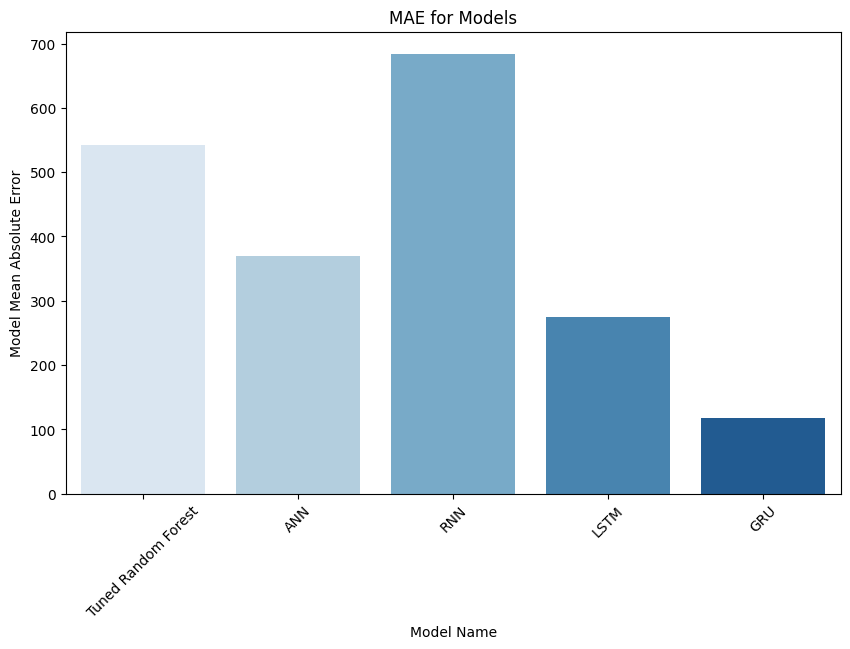

In [ ]:
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(final_results, x='Model Name', y='MAE', hue='Model Name', palette="Blues")
plt.xlabel("Model Name")
plt.ylabel("Model Mean Absolute Error")
plt.xticks(rotation=45)
plt.title("MAE for Models")
plt.show()

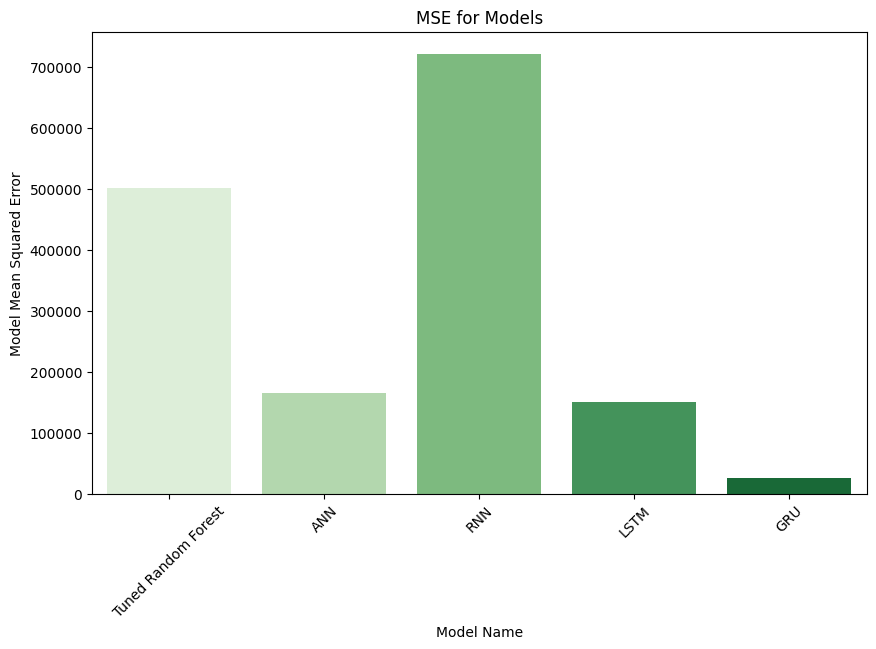

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(final_results, x='Model Name', y='MSE', hue='Model Name', palette="Greens")
plt.xlabel("Model Name")
plt.ylabel("Model Mean Squared Error")
plt.xticks(rotation=45)
plt.title("MSE for Models")
plt.show()

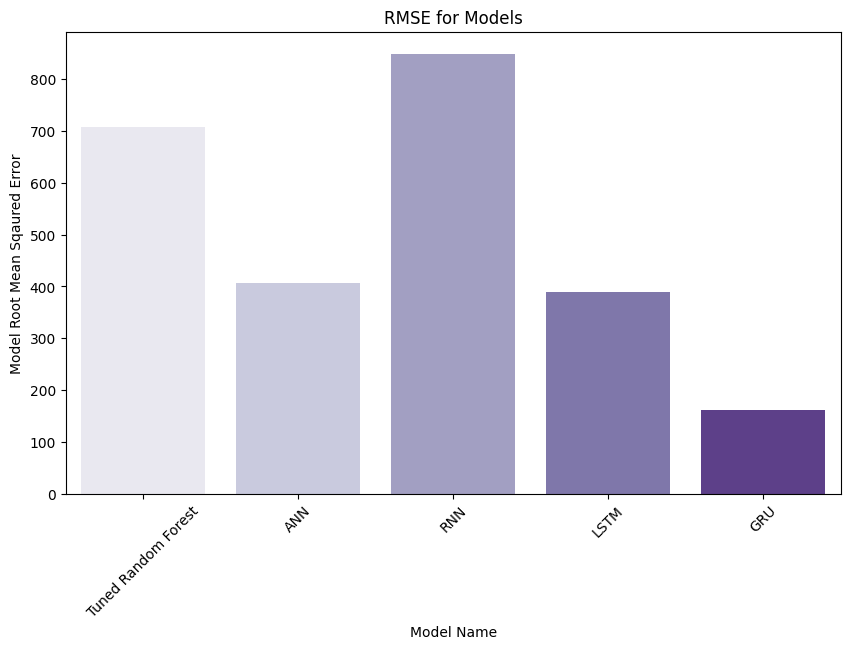

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(final_results, x='Model Name', y='RMSE', hue='Model Name', palette="Purples")
plt.xlabel("Model Name")
plt.ylabel("Model Root Mean Sqaured Error")
plt.xticks(rotation=45)
plt.title("RMSE for Models")
plt.show()

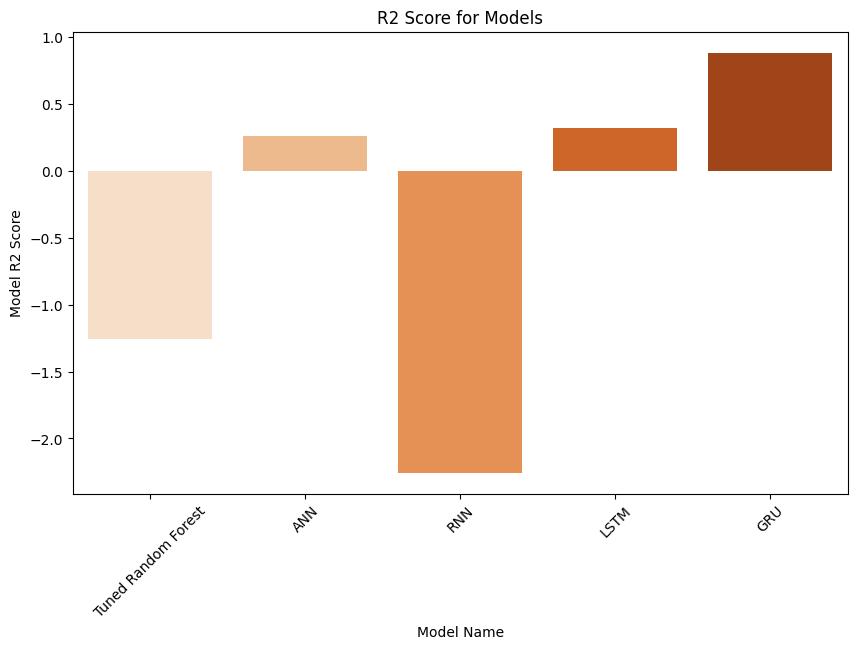

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(final_results, x='Model Name', y='R2', hue='Model Name', palette="Oranges")
plt.xlabel("Model Name")
plt.ylabel("Model R2 Score")
plt.xticks(rotation=45)
plt.title("R2 Score for Models")
plt.show()

In [ ]:
import joblib

joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

In [ ]:
gru_model.save('trained_gru_model.keras')
lstm_model.save('trained_lstm_model.keras')